# <font color = '#e64626'><center>QBUS6600 Individual Assignment</center></font>

## <center> Big W <center>

In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import ensemble
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV,Ridge
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.ensemble import StackingRegressor
import warnings
#warnings.filterwarnings('ignore')
from wordcloud import WordCloud
import re

In [89]:
import sys
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/big w/Sales by customer location test.csv')
sys.path.append('/content/drive/My Drive/big w/Media Investment.csv')
sys.path.append('/content/drive/My Drive/big w/Sales by customer location train.csv')
sys.path.append('/content/drive/My Drive/big w/Sales by store location.csv')
sys.path.append('/content/drive/My Drive/big w/Total personal income (weekly) by state and territory(a), 2021 Census.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
d1=pd.read_csv('/content/drive/My Drive/big w/Sales by customer location train.csv')
d2=pd.read_csv('/content/drive/My Drive/big w/Sales by customer location test.csv')
d3=pd.read_csv('/content/drive/My Drive/big w/Sales by store location.csv')
d4=pd.read_csv('/content/drive/My Drive/big w/Media Investment.csv')
d5=pd.read_csv('/content/drive/My Drive/big w/Total personal income (weekly) by state and territory(a), 2021 Census.csv',header=1)
dic=pd.read_excel('/content/drive/My Drive/big w/Data dictionary.xlsx')


In [91]:
d4['state'].value_counts()

NT          103
SA          103
WA          103
ACT         103
NSW         103
QLD         103
TAS         103
VIC         103
UNKNOWN     101
National     23
Name: state, dtype: int64

In [92]:
print(d5.shape)
d5

(14, 17)


,Unnamed: 0,Median income,Negative income,Nil income,$1-$149,$150-$299,$300-$399,$400-$499,$500-$649,$650-$799,$800-$999,"$1,000-$1,249","$1,250-$1,499","$1,500-$1,749","$1,750-$1,999","$2,000-$2,999","$3,000 or more"
0,New South Wales,813,"48,024","558,019","199,715","301,947","497,863","497,263","472,795","453,482","518,187","580,866","436,915","379,950","289,392","519,595","373,538"
1,Victoria,803,"40,097","462,585","181,402","259,576","393,575","398,650","378,559","366,570","437,356","483,105","365,266","321,293","229,793","392,855","263,112"
2,Queensland,787,"28,996","303,632","140,223","201,611","325,481","326,763","322,430","306,103","360,782","384,211","280,697","242,883","177,863","291,027","170,135"
3,South Australia,734,"9,293","103,721","50,776","81,493","131,617","135,058","121,526","111,354","128,716","141,776","101,079","82,849","58,086","87,386","47,071"
4,Western Australia,848,"14,775","175,789","74,433","106,129","153,779","149,720","146,826","135,161","155,856","182,352","143,853","132,068","100,717","190,276","127,181"
5,Tasmania,701,"3,018","29,744","14,983","25,490","44,367","46,543","40,553","37,358","41,024","44,639","30,046","24,860","17,270","23,812","11,468"
6,Northern Territory,936,"1,319","11,169","6,751","15,308","11,024","9,485","8,923","8,737","12,176","16,339","13,793","13,095","9,734","16,841","7,360"
7,Australian Capital Territory,"1,203","1,238","24,751","11,408","13,363","15,655","17,863","19,285","19,895","26,161","33,173","30,992","31,827","25,579","53,018","29,121"
8,Australia(b),805,"146,805","1,669,570","679,812","1,005,072","1,573,594","1,581,612","1,511,161","1,438,936","1,680,606","1,866,801","1,402,863","1,229,021","908,593","1,575,067","1,029,073"
9,Please note that there are small random adjustments made to all cell values to protect the confidentiality of data. These adjustments may cause the sum of rows or columns to differ by small amount...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
d1=d1.drop(columns=['total_sale_value_ex_gst'])
d2=d2.drop(columns=['total_sale_value_ex_gst'])
d3=d3.drop(columns=['total_sale_value_ex_gst'])
d3=d3.drop(columns=['store_longitude','store_latitude'])


In [94]:
d3=d3.rename(columns={'total_sale_value':'store_total_sale_value','total_promotional_sales_value':'store_total_promotional_sales_value'})
d3

,store_id,store_state,store_postcode,co_location_flag,sales_channel,distance_to_kmart,distance_to_target,store_total_sale_value,store_total_promotional_sales_value
0,f639b3bffb0910cb1de42fee016df58d,NSW,2171,NaN,Digital - Delivery,NaN,NaN,19893406.80,233280.34
1,dad2fd502d209b12ac27f451b0b9c17e,NSW,2325,False,Store,>5 KM,<1 KM,45805299.60,5820887.92
2,dad2fd502d209b12ac27f451b0b9c17e,NSW,2325,False,Digital - ClickCollect,>5 KM,<1 KM,3950499.23,36306.13
3,b03a75fccca587a511170aa5b7952210,NSW,2430,True,Store,>5 KM,<1 KM,53824089.33,7816228.29
4,b03a75fccca587a511170aa5b7952210,NSW,2430,True,Digital - ClickCollect,>5 KM,<1 KM,3910046.42,36379.29
5,a9bd0eeb3ce6858df275497bb2089ec4,NSW,2478,False,Store,<1 KM,<1 KM,45348355.65,6134004.10
6,a9bd0eeb3ce6858df275497bb2089ec4,NSW,2478,False,Digital - ClickCollect,<1 KM,<1 KM,2527004.26,20652.83
7,b095edb34fad0d4caab18a338f638bda,VIC,3350,False,Store,3-5 KM,<1 KM,57785312.99,8069459.54
8,b095edb34fad0d4caab18a338f638bda,VIC,3350,False,Digital - ClickCollect,3-5 KM,<1 KM,4683018.86,44715.04
9,74f74fee81632519012db76222dfd62c,VIC,3429,True,Digital - ClickCollect,>5 KM,<1 KM,4118702.59,43105.27


In [ ]:
#d3['store_id'].value_counts()
#d3.loc[d3['store_id']=='17b4adf18100c8673e3f2c72dff87722',:]

In [ ]:
#groupby 成一行
#d3_dummies=pd.get_dummies(d3,columns=['sales_channel'])
#d3_dummies

In [96]:
#保留数据 认为后面三列应该保留 对该列取和
adjusted_store_total_sale_value=d3['store_total_sale_value'].groupby(d3['store_id']).sum()
adjusted_store_total_sale_value
#adjusted_total_sale
d3 = d3.merge(adjusted_store_total_sale_value, on='store_id', how='left')
d3=d3.rename(columns={'store_total_sale_value_y':'adjusted_store_total_sale_value'})
d3=d3.drop(columns=['sales_channel','store_total_sale_value_x'])


#d3 = d3.merge(pd.DataFrame({'store_id': d3['store_id'], 'adjusted_total_sale': adjusted_total_sale}), on='store_id')
d3.head(10)

,store_id,store_state,store_postcode,co_location_flag,distance_to_kmart,distance_to_target,store_total_promotional_sales_value,adjusted_store_total_sale_value
0,f639b3bffb0910cb1de42fee016df58d,NSW,2171,NaN,NaN,NaN,233280.34,19893406.80
1,dad2fd502d209b12ac27f451b0b9c17e,NSW,2325,False,>5 KM,<1 KM,5820887.92,49755798.83
2,dad2fd502d209b12ac27f451b0b9c17e,NSW,2325,False,>5 KM,<1 KM,36306.13,49755798.83
3,b03a75fccca587a511170aa5b7952210,NSW,2430,True,>5 KM,<1 KM,7816228.29,57734135.75
4,b03a75fccca587a511170aa5b7952210,NSW,2430,True,>5 KM,<1 KM,36379.29,57734135.75
5,a9bd0eeb3ce6858df275497bb2089ec4,NSW,2478,False,<1 KM,<1 KM,6134004.10,47875359.91
6,a9bd0eeb3ce6858df275497bb2089ec4,NSW,2478,False,<1 KM,<1 KM,20652.83,47875359.91
7,b095edb34fad0d4caab18a338f638bda,VIC,3350,False,3-5 KM,<1 KM,8069459.54,62468331.85
8,b095edb34fad0d4caab18a338f638bda,VIC,3350,False,3-5 KM,<1 KM,44715.04,62468331.85
9,74f74fee81632519012db76222dfd62c,VIC,3429,True,>5 KM,<1 KM,43105.27,43067917.27


In [98]:
d3.drop_duplicates(subset=['store_id'],keep='first',inplace=True,ignore_index=True)
data_train=pd.merge(d1,d3,on=['store_id'],how='left')
data_test=pd.merge(d2,d3,on=['store_id'],how='left')

In [ ]:
#d3.loc[d3['store_id']=='536fcc1021bff60edb212ca9b2480757',:]

In [ ]:
#与train, test里面时间的format不一样
d4['week_ending']=pd.to_datetime(d4['week_ending'],format='%d/%m/%Y')
d4.drop_duplicates(subset=['week_ending','state'],keep='first',inplace=True,ignore_index=True)
#print(d4.shape) #没有重复的信息，还是948

data_train['financial_week_end_date']=pd.to_datetime(data_train['financial_week_end_date'],format='%Y-%m-%d')
data_test['financial_week_end_date']=pd.to_datetime(data_test['financial_week_end_date'],format='%Y-%m-%d')



In [ ]:
data_train['store_state'].value_counts()

In [ ]:
d4['state'].value_counts()

In [ ]:
data_train

In [ ]:
#增加media_amount_spend这信息
data_trainwithmedia=pd.merge(data_train,d4,
                    how='left',
                    left_on=['financial_week_end_date','store_state'],
                    right_on=['week_ending','state']
                    )
#data_train_1
data_trainwithmedia=data_trainwithmedia.drop(['week_ending','state'],axis=1)
print(data_trainwithmedia.shape)
data_trainwithmedia.head()

In [ ]:
data_testwithmedia=pd.merge(data_test,d4,
                    how='left',
                    left_on=['financial_week_end_date','store_state'],
                    right_on=['week_ending','state']
                    )
data_testwithmedia=data_testwithmedia.drop(['week_ending','state'],axis=1)
print(data_testwithmedia.shape)

In [ ]:
data_trainwithmedia['store_state'].value_counts()


In [ ]:
#d5
d5=d5.iloc[:8,:2]
d5=d5.rename(columns={'Unnamed: 0':'store_state'})
d5['store_state']=pd.Series(['NSW','VIC','QLD','SA','WA','TAS','NT','ACT'])
d5
#只有前8列对应的上，

In [ ]:
data_trainwithmedia_new=pd.merge(data_trainwithmedia,d5,how='left',on=['store_state'])
#print(data_trainwithmedia_new)
print(data_trainwithmedia_new.shape)
data_trainwithmedia_new.head()

In [ ]:
data_testwithmedia_new=pd.merge(data_testwithmedia,d5,how='left',on=['store_state'])
print(data_testwithmedia_new.shape)
data_testwithmedia_new.head()

In [ ]:
data_trainwithmedia_new.info()

In [ ]:
data_trainwithmedia_new.columns.values

In [ ]:
data_trainwithmedia_new.describe().round(3)

In [ ]:
data_trainwithmedia_new.isnull().sum().sort_values(ascending=False)

In [ ]:
data_trainwithmedia_new[data_trainwithmedia_new['customer_postcode'].isnull().values==True]

In [ ]:
data_testwithmedia_new.isnull().sum().sort_values(ascending=False)

In [ ]:
datatrain_missing = (data_trainwithmedia_new.isna().sum() / data_trainwithmedia_new.shape[0]).round(8)

datatrain_missing = pd.DataFrame(datatrain_missing, columns = ['missing_percentage'])
datatrain_missing = datatrain_missing[(datatrain_missing['missing_percentage'] != 0)].sort_values(by="missing_percentage" , ascending=False)

In [ ]:
datatrain_missing

In [ ]:
datatest_missing = (data_testwithmedia_new.isna().sum() / data_testwithmedia_new.shape[0]).round(8)

datatest_missing = pd.DataFrame(datatest_missing, columns = ['missing_percentage'])
datatest_missing = datatest_missing[(datatest_missing['missing_percentage'] != 0)].sort_values(by="missing_percentage" , ascending=False)

In [ ]:
datatest_missing

In [ ]:
data_trainwithmedia_new['sales_channel'].value_counts()

In [ ]:
data_trainwithmedia_new[data_trainwithmedia_new['customer_postcode'].isnull().values==True]

In [ ]:
n=d1.loc[d1['store_id']=='be30a998b7393750806a3058d926469f',:]
n['customer_state'].value_counts()
data_trainwithmedia_new.loc[data_trainwithmedia_new['store_id']=='be30a998b7393750806a3058d926469f',['customer_state']]='NSW'

data_trainwithmedia_new[data_trainwithmedia_new['customer_postcode'].isnull().values==True]

In [ ]:
a=d1.loc[d1['store_id']=='83822f5159c98d493a11ffbcd05df7f9',:]
a['customer_state'].value_counts()
data_trainwithmedia_new.loc[data_trainwithmedia_new['store_id']=='83822f5159c98d493a11ffbcd05df7f9',['customer_state']]='VIC'

data_trainwithmedia_new[data_trainwithmedia_new['customer_postcode'].isnull().values==True]

In [ ]:
c=d1.loc[d1['store_id']=='c2c49462eba817d37eb58cc8203802b4',:]
c
#c['customer_state'].value_counts()
#data_trainwithmedia_new.loc[data_trainwithmedia_new['customer_state']=='Other',['customer_state']]='VIC' #mode


#data_trainwithmedia_new[data_trainwithmedia_new['customer_postcode'].isnull().values==True]

In [ ]:
data_testwithmedia_new.loc[284253,['customer_state']]='VIC'
data_testwithmedia_new[data_testwithmedia_new['customer_postcode'].isnull().values==True] #mode


In [ ]:
#不纯在missingvalue，没有做营销，所有的nan都为0
data_trainwithmedia_new[data_trainwithmedia_new['media_amount_spend'].isnull().values==True]
#data_trainwithmedia_new_1=data_trainwithmedia_new
data_trainwithmedia_new['media_amount_spend_NA']=data_trainwithmedia_new['media_amount_spend'].isnull().astype(int)

data_trainwithmedia_new.loc[data_trainwithmedia_new['media_amount_spend'].isnull(),'media_amount_spend']=0.0
#data_trainwithmedia_new
#data_trainwithmedia_new[data_trainwithmedia_new['media_amount_spend'].isnull().values==True]



In [ ]:
#data_testwithmedia_new[data_testwithmedia_new['media_amount_spend'].isnull().values==True]
data_testwithmedia_new['media_amount_spend_NA']=data_testwithmedia_new['media_amount_spend'].isnull().astype(int)
data_testwithmedia_new.loc[data_testwithmedia_new['media_amount_spend'].isnull(),'media_amount_spend']=0.0
data_testwithmedia_new
#data_testwithmedia_new[data_testwithmedia_new['media_amount_spend'].isnull().values==True]



In [ ]:
data_testwithmedia_new['co_location_flag'].value_counts(dropna=False)


In [ ]:
data_trainwithmedia_new['co_location_flag']


In [ ]:
data_trainwithmedia_new['co_location_flag'].fillna('unkown',inplace=True)
data_testwithmedia_new['co_location_flag'].fillna('unkown',inplace=True)

In [ ]:
data_testwithmedia_new['co_location_flag'].value_counts(dropna=False)

In [ ]:
#price_lifestage_segment fill mv with mode
data_trainwithmedia_new['price_lifestage_segment'].fillna(data_trainwithmedia_new['price_lifestage_segment'].mode()[0],inplace=True)
data_testwithmedia_new['price_lifestage_segment'].fillna(data_testwithmedia_new['price_lifestage_segment'].mode()[0],inplace=True)

In [ ]:
data_testwithmedia_new['price_lifestage_segment'].value_counts(dropna=False)

In [ ]:
data_trainwithmedia_new[data_trainwithmedia_new['customer_postcode'].isnull().values==True]
#data_trainwithmedia_new['customer_postcode'].fillna(data_trainwithmedia_new['customer_postcode'].mode()[0],inplace=True)

In [ ]:
f=d1.loc[d1['store_id']=='be30a998b7393750806a3058d926469f',:]
f['customer_postcode'].value_counts()

In [ ]:
data_trainwithmedia_new.loc[10212,['customer_postcode']]=3000.0
data_trainwithmedia_new.loc[311002,['customer_postcode']]=3000.0
data_trainwithmedia_new.loc[902635,['customer_postcode']]=3000.0
data_trainwithmedia_new.loc[1357169,['customer_postcode']]=3000.0
data_trainwithmedia_new.loc[1641168,['customer_postcode']]=3000.0
data_trainwithmedia_new.loc[918724,['customer_postcode']]=3810.0
data_trainwithmedia_new.loc[1314718,['customer_postcode']]=2099.0

In [ ]:
data_trainwithmedia_new['customer_postcode'].isnull().sum()

In [ ]:
data_testwithmedia_new[data_testwithmedia_new['customer_postcode'].isnull().values==True]

In [ ]:
g=d2.loc[d2['store_id']=='c2c49462eba817d37eb58cc8203802b4',:]
g['customer_postcode'].value_counts()

In [ ]:
data_testwithmedia_new.loc[284253,['customer_postcode']]=3000.0

In [ ]:
data_testwithmedia_new['customer_postcode'].isnull().sum()

In [ ]:
#missing value
#media_amount_spend

#data_trainwithmedia_new['media_amount_spend'].value_counts(dropna=False)

#co_location_flag
#data_trainwithmedia_new['co_location_flag'].value_counts(dropna=False)
#price_lifestage_segment
#data_trainwithmedia_new['price_lifestage_segment'].value_counts(dropna=False)
#customer_postcode
#data_trainwithmedia_new['customer_postcode'].value_counts(dropna=False)




In [ ]:

#####EDA

In [ ]:
#change data type

In [ ]:
categorical=data_trainwithmedia_new.loc[:,data_trainwithmedia_new.dtypes =='object' ]
categorical.info()

In [ ]:
numercial=data_trainwithmedia_new.loc[:,data_trainwithmedia_new.dtypes !='object' ]
numercial.info()

In [ ]:
#median income object to float
#categorical['Median income'].value_counts()  #1,203
data_trainwithmedia_new['Median income']=data_trainwithmedia_new['Median income'].str.replace(',','').astype(float)
data_testwithmedia_new['Median income']=data_testwithmedia_new['Median income'].str.replace(',','').astype(float)

In [ ]:
categorical=data_trainwithmedia_new.loc[:,data_trainwithmedia_new.dtypes =='object' ]
categorical.info()

In [ ]:
numercial=data_trainwithmedia_new.loc[:,data_trainwithmedia_new.dtypes !='object' ]
numercial.info()

In [ ]:
#customer_postcode float to string

data_trainwithmedia_new['customer_postcode']=data_trainwithmedia_new['customer_postcode'].astype(int).astype(str)
data_testwithmedia_new['customer_postcode']=data_testwithmedia_new['customer_postcode'].astype(int).astype(str)

In [ ]:
# store_postcode int to string
data_trainwithmedia_new['store_postcode']=data_trainwithmedia_new['store_postcode'].astype(str)
data_testwithmedia_new['store_postcode']=data_testwithmedia_new['store_postcode'].astype(str)

In [ ]:
#######

In [ ]:
sns.set(style='whitegrid')
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth',200)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [ ]:
#target
y=data_trainwithmedia_new['total_sale_value']
y.head()

In [ ]:
data_trainwithmedia_new['total_sale_value'].describe()

In [ ]:
y.describe()

In [ ]:
y.skew()


In [ ]:
y.kurt()

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(y, bins=200);
plt.xlabel('Total Sale Value (AUD)',fontsize=10)
plt.ylabel('Count',fontsize=10)
plt.title('Histogram of Total Sale Value(AUD)',fontsize=15)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(np.log(y), bins=200);
plt.xlabel('Log Total Sale Value (AUD)',fontsize=10)
plt.ylabel('Count',fontsize=10)
plt.title('Histogram of Log Total Sale Value(AUD)',fontsize=15)
plt.show()

In [ ]:
y_log=np.log(y)
#data_trainwithmedia_new['log_total_sale_value']=
#y_log.head()

In [ ]:
sns.kdeplot(y, shade=True, color='blue', label='Sepal Length')

In [ ]:
sns.kdeplot(y_log, shade=True, color='blue', label='Sepal Length')

In [ ]:
y1= data_trainwithmedia_new['total_sale_value']/1e4
# price per million

sale_skew=y1.skew() #check skewness
sale_mean=y1.mean()
sale_median=y1.median()


plt.figure(figsize = (15, 6))
plt.hist(y1, bins = 200, color = 'tab:blue', alpha = 0.5, edgecolor = 'black')

#draw a vertical line of mean
plt.plot([sale_mean,sale_mean],[0,700000],color='black')
          # ^ x-cooridnates        ^ y-coordinates
#create a text box that output the value of mean

plt.annotate('Mean: {:.5f}'.format(sale_mean), (sale_mean*1.6, 400000), backgroundcolor = 'white',fontsize=17)
# draw a vertical line for median
#create a text box that dispaly the value of median
plt.plot([sale_median,sale_median],[0,700000],color='black')
plt.annotate('Median: {:.5f}'.format(sale_median),(sale_median*1,550000),backgroundcolor='white',fontsize=17)
plt.ylabel('Count',fontsize=20)
plt.xlabel('total_sale_value (ten thousand AUD)',fontsize=20)
plt.title('Total Sale Value (Skewness = {:.2f})'.format(sale_skew),fontsize=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0, 700000])
plt.xlim([0, 12])
plt.tight_layout()
plt.savefig('plot.png')

In [ ]:
#numercial
numercial.info()

In [102]:
categorical.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1827592 entries, 0 to 1827591
Data columns (total 8 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   store_id                 object
 1   sales_channel            object
 2   customer_state           object
 3   price_lifestage_segment  object
 4   store_state              object
 5   co_location_flag         object
 6   distance_to_kmart        object
 7   distance_to_target       object
dtypes: object(8)
memory usage: 125.5+ MB


In [ ]:
#categorical
#0-1 variable
#co_location_flag
data_trainwithmedia_new['co_location_flag'].value_counts()

In [101]:
cor=data_trainwithmedia_new.corr()['total_sale_value'].sort_values(ascending=False).round(2)
print(cor)

total_sale_value                       1.00
transaction_count                      0.95
customer_count                         0.93
total_promotional_sales_value          0.88
log_total_sale_value                   0.75
media_amount_spend                     0.02
store_total_promotional_sales_value    0.02
adjusted_store_total_sale_value        0.01
media_amount_spend_NA                 -0.01
Median income                         -0.03
Name: total_sale_value, dtype: float64


In [100]:
data_trainwithmedia_new['log_total_sale_value']=np.log(data_trainwithmedia_new['total_sale_value'])
corr=data_trainwithmedia_new.corr()['log_total_sale_value'].sort_values(ascending=False).round(2)
print(corr)
#data_trainwithmedia_new

log_total_sale_value                   1.00
customer_count                         0.75
total_sale_value                       0.75
transaction_count                      0.75
total_promotional_sales_value          0.65
media_amount_spend                     0.03
store_total_promotional_sales_value    0.02
adjusted_store_total_sale_value        0.00
media_amount_spend_NA                 -0.01
Median income                         -0.03
Name: log_total_sale_value, dtype: float64


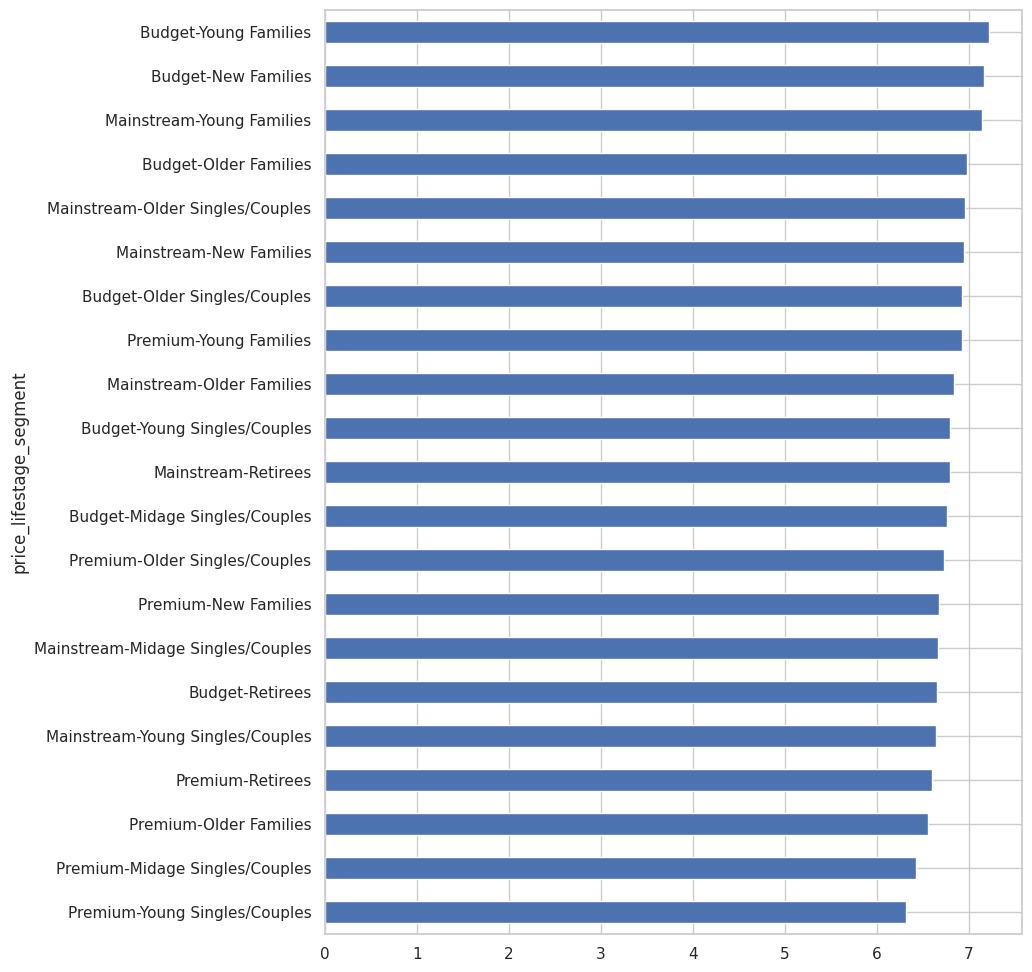

In [121]:
data_trainwithmedia_new.groupby('price_lifestage_segment')['log_total_sale_value'].mean().sort_values().plot(kind='barh',figsize=(9,12))
plt.show()

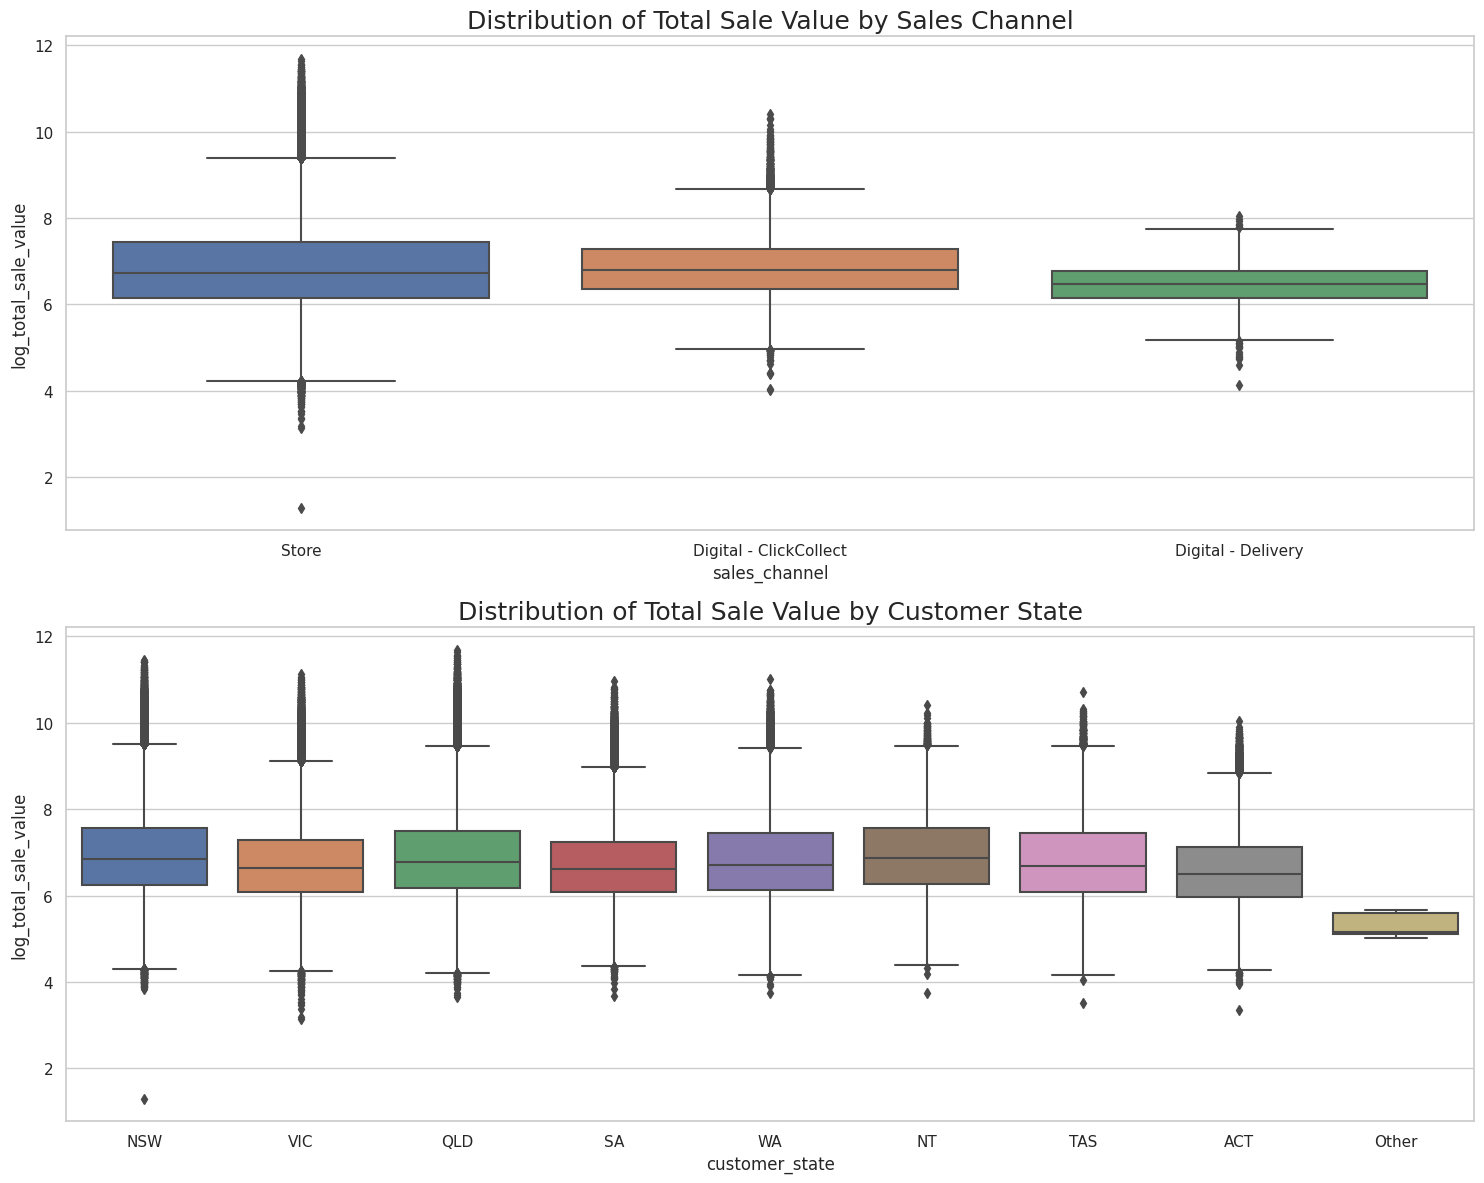

In [120]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(15,12))
sns.boxplot(x='sales_channel',y='log_total_sale_value',data=data_trainwithmedia_new,ax=ax[0])
ax[0].set_title('Distribution of Total Sale Value by Sales Channel',fontsize=18)
ax[0].set_ylabel('log_total_sale_value')

sns.boxplot(x='customer_state',y='log_total_sale_value',data=data_trainwithmedia_new,ax=ax[1])
ax[1].set_title('Distribution of Total Sale Value by Customer State',fontsize=18)
ax[1].set_ylabel('log_total_sale_value')

plt.tight_layout()
plt.show()

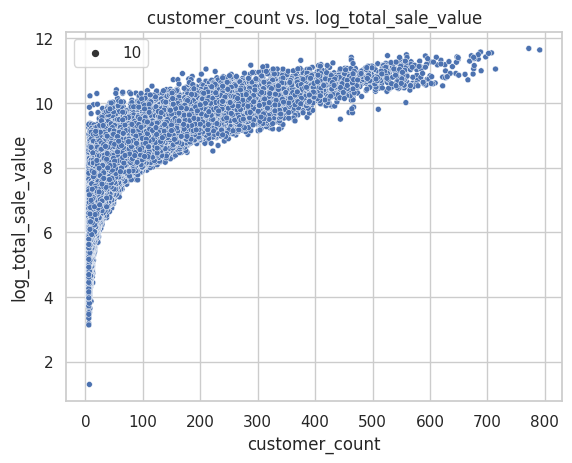

In [ ]:
sns.scatterplot(data=data_trainwithmedia_new,x='customer_count',y='log_total_sale_value',s=10)
plt.title('customer_count vs. log_total_sale_value')
plt.show()